# k6 Metrics Visualization

Set `RESULTS_ROOT` to auto-discover all runs, or populate `METRIC_FILES` with explicit `(label, path)` pairs.

In [1]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.4

In [2]:
BASE_DIR = Path.cwd().resolve().parent
RESULTS_ROOT = BASE_DIR / "results"
METRIC_FILES = []  # [(label, path), ...] - overrides auto-discovery

In [3]:
OUTPUT_DIR = RESULTS_ROOT / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _slugify(text, max_len=80):
    safe = re.sub(r"[^a-zA-Z0-9]+", "-", str(text).strip().lower()).strip("-")
    if not safe:
        safe = "plot"
    return safe[:max_len]

def save_svg(fig, title, labels=None):
    labels = list(labels) if labels else []
    parts = [_slugify(title)]
    if labels:
        labels_slug = "-".join(_slugify(label, 40) for label in labels)
        if labels_slug:
            parts.append(labels_slug[:120])
    filename = "__".join(parts) + ".svg"
    out_path = OUTPUT_DIR / filename
    fig.savefig(out_path, format="svg", bbox_inches="tight")
    print(f"saved: {out_path}")
    return out_path

In [4]:
print("Notebook CWD:", Path.cwd())
print("RESULTS_ROOT:", RESULTS_ROOT)
print("Exists:", RESULTS_ROOT.exists())

Notebook CWD: c:\Users\mathi\source\repos\FileShare\src\k6\notebooks
RESULTS_ROOT: C:\Users\mathi\source\repos\FileShare\src\k6\results
Exists: True


In [5]:
def load_metrics(path, metrics=None, label=None, skip_seconds=0):
    print(f"Loading: {path}")

    chunks = []
    total_rows = 0
    kept_rows = 0

    for i, chunk in enumerate(pd.read_json(path, lines=True, chunksize=50_000)):
        total_rows += len(chunk)

        chunk = chunk[chunk["type"] == "Point"]

        if metrics is not None:
            chunk = chunk[chunk["metric"].isin(metrics)]

        kept_rows += len(chunk)

        if chunk.empty:
            continue

        exp = pd.DataFrame(chunk["data"].tolist())
        exp = exp[["time", "value"]]  # drop tags early

        exp["metric"] = chunk["metric"].values
        exp["time"] = pd.to_datetime(exp["time"], utc=True)

        # 👉 ADD LABEL HERE
        if label is not None:
            exp["label"] = label

        chunks.append(exp)

        if i % 10 == 0:
            print(f"  processed {total_rows:,} rows...")

    if not chunks:
        print("  no matching data found")
        return pd.DataFrame()

    df = pd.concat(chunks, ignore_index=True)
    df = df.sort_values("time").reset_index(drop=True)
    df["time_sec"] = (df["time"] - df["time"].min()).dt.total_seconds()

        # 👉 REMOVE INITIAL SPIKE
    if skip_seconds > 0:
        df = df[df["time_sec"] >= skip_seconds].reset_index(drop=True)

    print(f"  done: kept {kept_rows:,} / {total_rows:,} rows")

    return df

In [6]:

if METRIC_FILES:
    files = [(label, Path(p)) for label, p in METRIC_FILES]
else:
    files = []
    for fp in sorted(Path(RESULTS_ROOT).rglob("metrics.json")):
        parts = fp.parts
        label = "/".join(parts[-5:-1])
        files.append((label, fp))

In [7]:
TARGET_METRICS = ["http_req_duration","http_reqs"]

runs = {
    "direct/ http (stress)":  load_metrics(RESULTS_ROOT / "storage_direct_ping/http/stress/20260429-235315/metrics.json", TARGET_METRICS, "direct / http (stress)",5),
    "gateway/ http (stress)":  load_metrics(RESULTS_ROOT / "gateway_storage_ping/http/stress/20260429-234659/metrics.json", TARGET_METRICS, "gateway / http (stress)",5),
}

Loading: C:\Users\mathi\source\repos\FileShare\src\k6\results\storage_direct_ping\http\stress\20260429-235315\metrics.json


FileNotFoundError: File C:\Users\mathi\source\repos\FileShare\src\k6\results\storage_direct_ping\http\stress\20260429-235315\metrics.json does not exist

In [ ]:
def get_metric(df, name):
    return df[df["metric"] == name].copy()

In [ ]:
def get_label(df, name):
    return df[df["label"].str.startswith(name)].copy()

In [ ]:
direct_runs = {k: v for k, v in runs.items() if k.startswith("direct")}

## Summary Stats

In [ ]:
rows = []
for label, fp in files:
    summary_path = fp.parent / "summary.json"
    if summary_path.exists():
        print("found!")
        data = json.loads(summary_path.read_text())
        vals = data.get("metrics", {}).get("http_req_duration", {}).get("values", {})
        reqs = data.get("metrics", {}).get("http_reqs", {}).get("values", {})
        rows.append({
            "run": label,
            "count": int(reqs.get("count", 0)),
            "rate (req/s)": round(reqs.get("rate", 0), 2),
            "mean (ms)": round(vals.get("avg", 0), 2),
            "p50 (ms)": round(vals.get("med", 0), 2),
            "p90 (ms)": round(vals.get("p(90)", 0), 2),
            "p95 (ms)": round(vals.get("p(95)", 0), 2),
            "max (ms)": round(vals.get("max", 0), 2),
        })
    else:
        dur = get_metric(runs[label], "http_req_duration")["value"].dropna()
        reqs_count = len(get_metric(runs[label], "http_reqs"))
        rows.append({
            "run": label,
            "count": reqs_count,
            "rate (req/s)": None,
            "mean (ms)": round(dur.mean(), 2) if not dur.empty else None,
            "p50 (ms)": round(np.percentile(dur, 50), 2) if not dur.empty else None,
            "p90 (ms)": round(np.percentile(dur, 90), 2) if not dur.empty else None,
            "p95 (ms)": round(np.percentile(dur, 95), 2) if not dur.empty else None,
            "max (ms)": round(dur.max(), 2) if not dur.empty else None,
        })

pd.DataFrame(rows).set_index("run")

found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!
found!


,count,rate (req/s),mean (ms),p50 (ms),p90 (ms),p95 (ms),max (ms)
run,,,,,,,
gateway_storage_get_file/http/spike/20260505-115754,0,0,0,0,0,0,0
gateway_storage_get_file/http/stress/20260429-234342,0,0,0,0,0,0,0
gateway_storage_get_file/https/spike/20260505-114332,0,0,0,0,0,0,0
gateway_storage_get_file/https/stress/20260429-233642,0,0,0,0,0,0,0
gateway_storage_get_file/mtls/spike/20260505-111651,0,0,0,0,0,0,0
gateway_storage_get_file/mtls/stress/20260429-232149,0,0,0,0,0,0,0
gateway_storage_ping/http/spike/20260505-120008,0,0,0,0,0,0,0
gateway_storage_ping/http/stress/20260429-234659,0,0,0,0,0,0,0
gateway_storage_ping/https/spike/20260505-114647,0,0,0,0,0,0,0


## Response Time Distribution

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\response-time-distribution-http-req-duration-ms__direct-http-stress-gateway-http-stress.svg


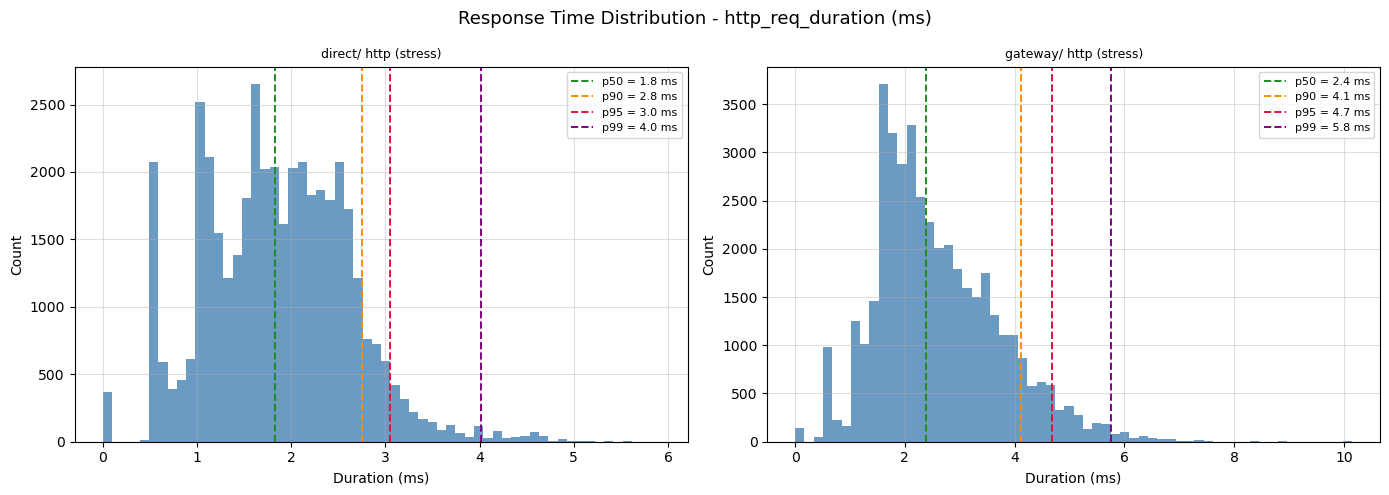

In [ ]:
n = max(1, len(runs))
fig, axes = plt.subplots(1, n, figsize=(7 * n, 5), squeeze=False)
fig.suptitle("Response Time Distribution - http_req_duration (ms)", fontsize=13)

# Define the percentiles and their line colors
percentile_styles = {
    50: "forestgreen",
    90: "darkorange",
    95: "crimson",
    99: "purple"
}

for ax, (label, df) in zip(axes[0], runs.items()):
    dur = get_metric(df, "http_req_duration")["value"].dropna()
    if dur.empty:
        ax.set_title(f"{label}\n(no data)")
        continue
        
    ax.hist(dur, bins=60, edgecolor="none", color="steelblue", alpha=0.8)
    
    # Calculate and plot all percentiles
    for p, color in percentile_styles.items():
        val = np.percentile(dur, p)
        ax.axvline(val, color=color, linestyle="--", linewidth=1.4, label=f"p{p} = {val:.1f} ms")
        
    ax.set_xlabel("Duration (ms)")
    ax.set_ylabel("Count")
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
save_svg(fig, "Response Time Distribution - http_req_duration (ms)", labels=runs.keys())
plt.show()

In [ ]:
zoom_limit = 180  # ms
n = max(1, len(runs))

fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), squeeze=False)
fig.suptitle("Request Duration Distribution (Full vs Zoomed)", fontsize=14)

for i, (label, df) in enumerate(runs.items()):
    ax_full = axes[i, 0]
    ax_zoom = axes[i, 1]

    dur = get_metric(df, "http_req_duration")["value"].dropna()
    if dur.empty:
        ax_full.set_title(f"{label}\n(no data)")
        ax_zoom.set_title(f"{label}\n(no data)")
        continue
        

    # Percentiles
    p50 = np.percentile(dur, 50)
    

    ax_full.hist(dur, bins=60, edgecolor="none", color="steelblue", alpha=0.8)
    ax_full.axvline(p50, color="green",linestyle="--", label=f"median = {p50:.1f} ms")
    ax_full.set_xlabel("Duration (ms)")
    ax_full.set_ylabel("Count")
    ax_full.set_title(label, fontsize=9)
    ax_full.legend(fontsize=8)

    # --- ZOOMED --- 
    dur_zoom = dur[dur <= zoom_limit]

    p50_zoom = np.percentile(dur_zoom, 50)
    
    ax_zoom.hist(dur_zoom, bins=60, edgecolor="none", alpha=0.8)

    ax_zoom.axvline(p50_zoom, color="green", linestyle="--", label=f"median = {p50_zoom:.1f} ms")
  
    ax_zoom.set_xlim(0, zoom_limit)
    ax_zoom.set_title(f"{label} (Zoom ≤ {zoom_limit} ms)")
    ax_zoom.set_xlabel("Duration (ms)")
    ax_zoom.set_ylabel("Count")

    # Tail info
    pct_zoom = 100 * len(dur_zoom) / len(dur)
    pct_tail = 100 - pct_zoom
    ax_zoom.legend(fontsize=8, title=f"{pct_zoom:.1f}% shown\n{pct_tail:.1f}% tail")

plt.tight_layout()
plt.show()

## Percentile Comparison

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\response-time-percentiles-by-run-ms__direct-http-stress-gateway-http-stress.svg


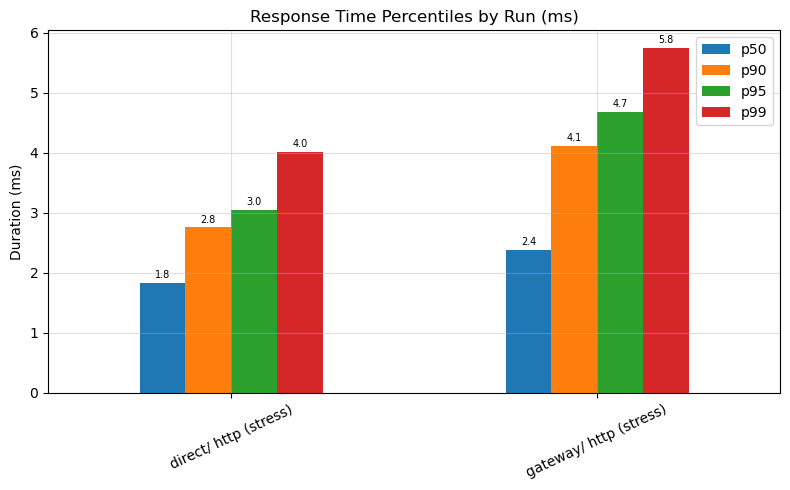

In [ ]:
pct_rows = {}
for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")["value"].dropna()
    if dur.empty:
        continue
    pct_rows[label] = {
        "p50": np.percentile(dur, 50),
        "p90": np.percentile(dur, 90),
        "p95": np.percentile(dur, 95),
        "p99": np.percentile(dur, 99),
    }

if pct_rows:
    pct_df = pd.DataFrame(pct_rows).T
    ax = pct_df.plot(kind="bar", figsize=(max(8, 2 * len(pct_rows)), 5), rot=25)
    ax.set_title("Response Time Percentiles by Run (ms)")
    ax.set_ylabel("Duration (ms)")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", fontsize=7, padding=2)
    plt.tight_layout()
    save_svg(ax.get_figure(), "Response Time Percentiles by Run (ms)", labels=pct_rows.keys())
    plt.show()

## Response Time Over Time

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\response-time-over-time-smoothed-20-sample-rolling-mean__direct-http-stress-gateway-http-stress.svg


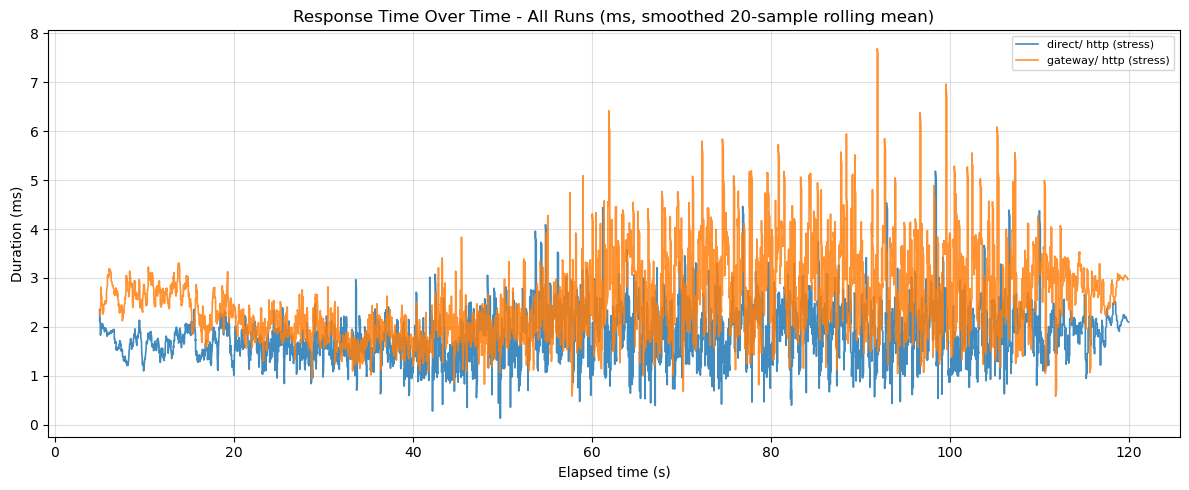

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")
    if dur.empty:
        continue
    ts = dur.set_index("time_sec")["value"].sort_index()
    smoothed = ts.rolling(window=20, min_periods=1).mean()
    ax.plot(smoothed.index, smoothed.values, label=label, linewidth=1.2, alpha=0.85)

ax.set_title("Response Time Over Time - All Runs (ms, smoothed 20-sample rolling mean)")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Duration (ms)")
ax.legend(fontsize=8)
plt.tight_layout()
save_svg(fig, "Response Time Over Time - smoothed 20-sample rolling mean", labels=runs.keys())
plt.show()

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\average-response-time-over-time-log-scale__direct-http-stress-gateway-http-stress.svg


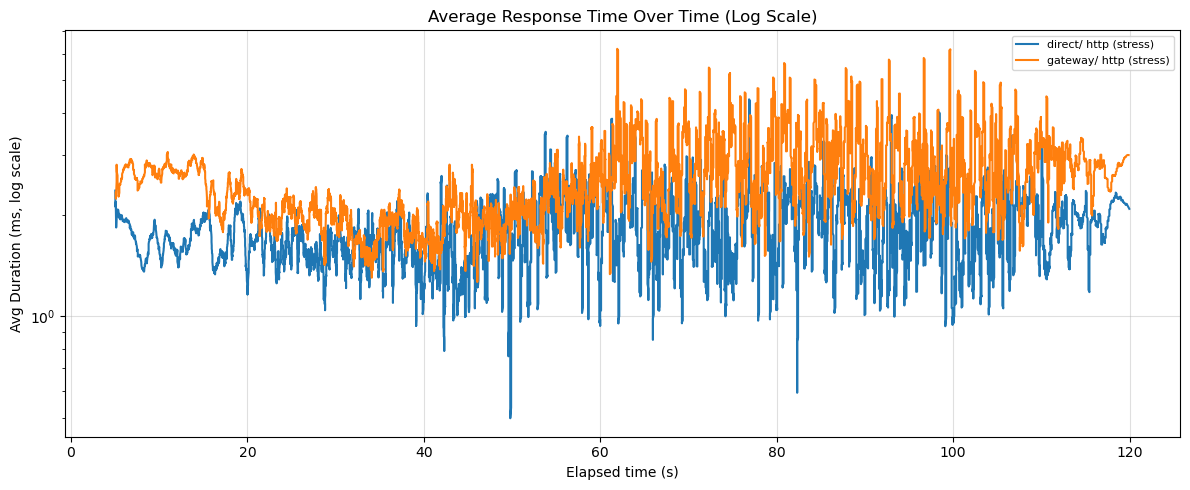

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")
    
    # Compute rolling average (adjust window as needed)
    dur["avg"] = dur["value"].rolling(window=50, min_periods=1).mean()

    ax.plot(
        dur["time_sec"],
        dur["avg"],
        label=label,
        linewidth=1.5
    )

# Log scale on Y axis
ax.set_yscale("log")

ax.set_title("Average Response Time Over Time (Log Scale)")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Avg Duration (ms, log scale)")
ax.legend(fontsize=8)

plt.tight_layout()
save_svg(fig, "Average Response Time Over Time (Log Scale)", labels=runs.keys())
plt.show()

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\response-time-over-time-all-runs__direct-http-stress-gateway-http-stress.svg


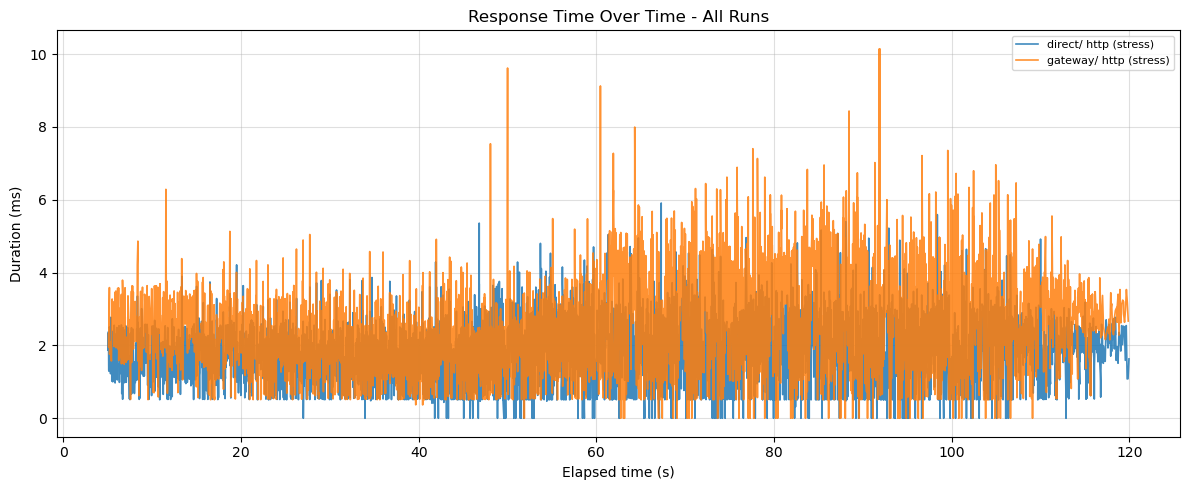

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")

    ax.plot(dur["time_sec"], dur["value"], label=label, linewidth=1.2, alpha=0.85)

ax.set_title("Response Time Over Time - All Runs")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Duration (ms)")
ax.legend(fontsize=8)
plt.tight_layout()
save_svg(fig, "Response Time Over Time - All Runs", labels=runs.keys())
plt.show()

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\response-time-over-time-p95-per-1s-bucket__direct-http-stress-gateway-http-stress.svg


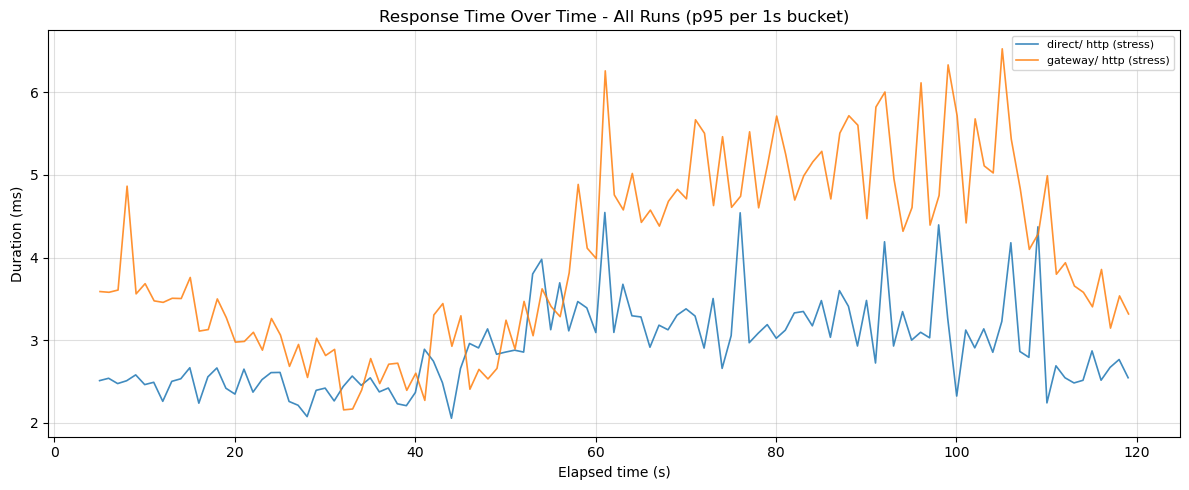

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")
    if dur.empty:
        continue

    ts = dur.set_index("time_sec")["value"].sort_index()

    # convert to consistent time bins (1s)
    ts.index = pd.to_timedelta(ts.index, unit="s")

    p95 = ts.resample("1s").quantile(0.95)

    ax.plot(
        p95.index.total_seconds(),
        p95.values,
        label=label,
        linewidth=1.2,
        alpha=0.85
    )

ax.set_title("Response Time Over Time - All Runs (p95 per 1s bucket)")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Duration (ms)")
ax.legend(fontsize=8)

plt.tight_layout()
save_svg(fig, "Response Time Over Time - p95 per 1s bucket", labels=runs.keys())
plt.show()

## TLS / Connection Timing Breakdown

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\mean-request-timing-breakdown-per-run-ms__direct-http-stress-gateway-http-stress.svg


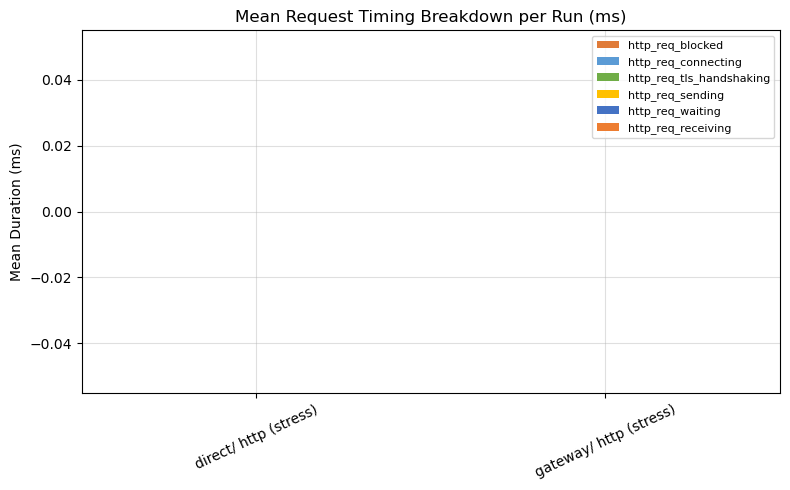

In [ ]:
timing_metrics = [
    "http_req_blocked",
    "http_req_connecting",
    "http_req_tls_handshaking",
    "http_req_sending",
    "http_req_waiting",
    "http_req_receiving",
]
colors = ["#e07b39", "#5b9bd5", "#70ad47", "#ffc000", "#4472c4", "#ed7d31"]

timing_data = {}
for label, df in runs.items():
    row = {m: get_metric(df, m)["value"].dropna().mean() or 0 for m in timing_metrics}
    timing_data[label] = row

timing_df = pd.DataFrame(timing_data).T
ax = timing_df.plot(kind="bar", stacked=True, figsize=(max(8, 2 * len(timing_data)), 5), color=colors, rot=25)
plt.title("Mean Request Timing Breakdown per Run (ms)")
plt.ylabel("Mean Duration (ms)")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
save_svg(ax.get_figure(), "Mean Request Timing Breakdown per Run (ms)", labels=timing_data.keys())
plt.show()

## Request Rate Over Time

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\request-rate-over-time-requests-per-second__direct-http-stress-gateway-http-stress.svg


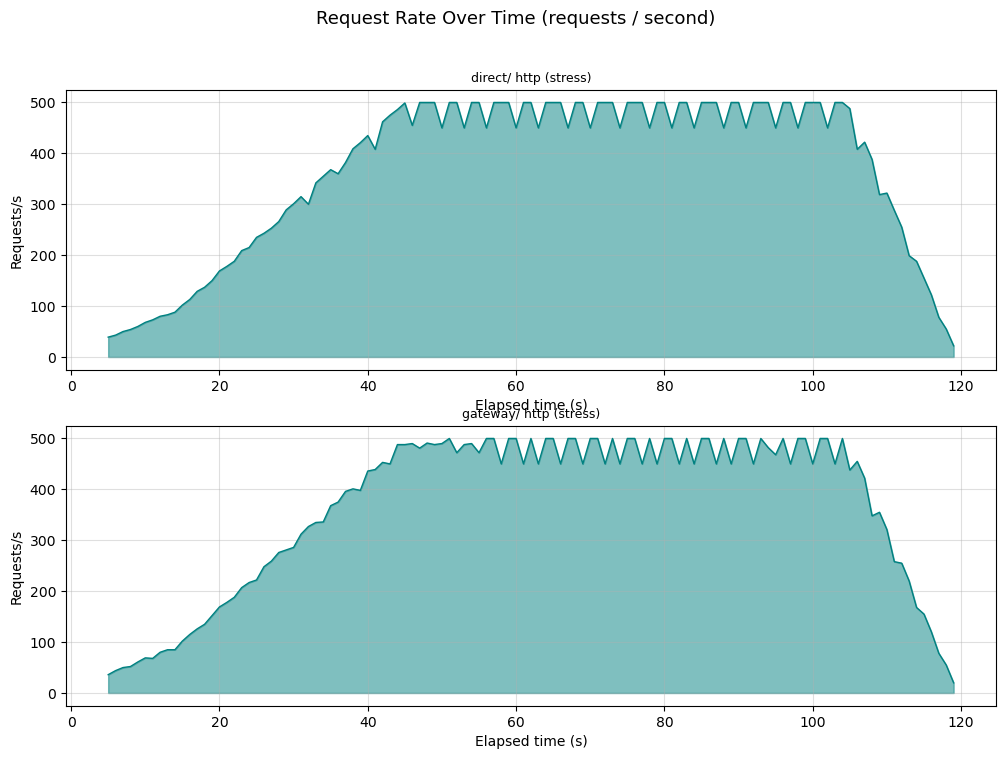

In [ ]:
n = max(1, len(runs))
fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), squeeze=False)
fig.suptitle("Request Rate Over Time (requests / second)", fontsize=13)

for ax, (label, df) in zip(axes[:, 0], runs.items()):
    reqs = get_metric(df, "http_reqs").copy()
    if reqs.empty:
        ax.set_title(f"{label} - no data")
        continue
    reqs["bucket"] = reqs["time_sec"].astype(int)
    rate = reqs.groupby("bucket")["value"].sum()
    ax.fill_between(rate.index, rate.values, alpha=0.5, color="teal")
    ax.plot(rate.index, rate.values, color="teal", linewidth=1)
    ax.set_xlabel("Elapsed time (s)")
    ax.set_ylabel("Requests/s")
    ax.set_title(label, fontsize=9)

# plt.tight_layout()
save_svg(fig, "Request Rate Over Time (requests per second)", labels=runs.keys())
plt.show()

## Check Pass Rate

In [ ]:
check_rows = {}
for label, df in runs.items():
    checks = get_metric(df, "checks")
    if checks.empty:
        continue
    total = len(checks)
    passed = (checks["value"] == 1).sum()
    check_rows[label] = {
        "passed": int(passed),
        "failed": int(total - passed),
        "pass_rate_%": 100 * passed / total if total else 0,
    }

if check_rows:
    check_df = pd.DataFrame(check_rows).T
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    check_df[["passed", "failed"]].plot(kind="bar", ax=ax1, color=["#70ad47", "#e07b39"], rot=25)
    ax1.set_title("Check Results")
    ax1.set_ylabel("Count")

    ax2.bar(range(len(check_df)), check_df["pass_rate_%"], color="steelblue")
    ax2.set_xticks(range(len(check_df)))
    ax2.set_xticklabels(check_df.index, rotation=25, ha="right", fontsize=8)
    ax2.axhline(98, color="crimson", linestyle="--", linewidth=1.2, label="98% threshold")
    ax2.set_ylim(0, 102)
    ax2.set_ylabel("Pass Rate (%)")
    ax2.set_title("Check Pass Rate")
    ax2.legend(fontsize=8)
    for i, v in enumerate(check_df["pass_rate_%"]):
        ax2.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

    plt.tight_layout()
    save_svg(fig, "Check Pass Rate", labels=check_rows.keys())
    plt.show()

## Per-Operation Breakdown

In [ ]:
op_rows = []
for label, df in runs.items():
    dur = get_metric(df, "http_req_duration")
    if "tags.operation" not in dur.columns:
        continue
    for op, grp in dur.groupby("tags.operation"):
        vals = grp["value"].dropna()
        if vals.empty:
            continue
        op_rows.append({
            "run": label,
            "operation": op,
            "p50": np.percentile(vals, 50),
            "p95": np.percentile(vals, 95),
            "p99": np.percentile(vals, 99),
        })

if op_rows:
    op_df = pd.DataFrame(op_rows)
    for pct in ["p50", "p95"]:
        pivot = op_df.pivot(index="run", columns="operation", values=pct)
        ax = pivot.plot(kind="bar", figsize=(max(8, 2 * len(pivot)), 5), rot=25)
        ax.set_title(f"{pct} Response Time per Operation (ms)")
        ax.set_ylabel("Duration (ms)")
        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f", fontsize=7, padding=2)
        plt.tight_layout()
        save_svg(ax.get_figure(), f"{pct} Response Time per Operation (ms)", labels=pivot.index)
        plt.show()
else:
    print("No per-operation data (only available for storage_direct_files / gateway_storage_files runs).")

No per-operation data (only available for storage_direct_files / gateway_storage_files runs).


## Multi-Run Percentile Comparison

saved: C:\Users\jacob\Documents\GitHub\FileShare\src\k6\results\plots\percentile-comparison-across-runs-ms__direct-http-stress-gateway-http-stress.svg


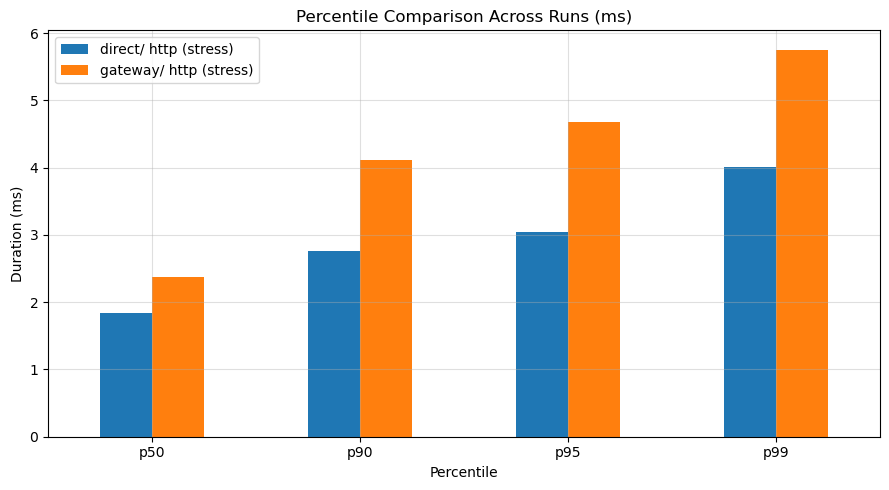

In [ ]:
if len(pct_rows) > 1:
    pct_df2 = pd.DataFrame(pct_rows)  # columns = labels, rows = p50/p90/p95/p99
    ax = pct_df2.plot(kind="bar", figsize=(9, 5), rot=0)
    ax.set_title("Percentile Comparison Across Runs (ms)")
    ax.set_ylabel("Duration (ms)")
    ax.set_xlabel("Percentile")
    plt.tight_layout()
    save_svg(ax.get_figure(), "Percentile Comparison Across Runs (ms)", labels=pct_rows.keys())
    plt.show()
else:
    print("Load at least 2 runs to see the multi-run comparison.")

In [ ]:
None